In [ ]:
import numpy as np
from scipy import stats

# 1. Arreglo del 1 al 1000 y suma total
arr = np.arange(1, 1001)
suma_total = np.sum(arr)
print("1️⃣ Suma total de los elementos:", suma_total)

# 2. Media, mediana y moda
datos = np.array([2, 4, 4, 6, 8, 8, 8, 10])
media = np.mean(datos)
mediana = np.median(datos)
moda = stats.mode(datos, keepdims=True)[0][0]
print("\n2️⃣ Media:", media)
print("   Mediana:", mediana)
print("   Moda:", moda)

# 3. Varianza y desviación estándar
varianza = np.var(datos)
desviacion_estandar = np.std(datos)
print("\n3️⃣ Varianza:", varianza)
print("   Desviación estándar:", desviacion_estandar)

1️⃣ Suma total de los elementos: 500500

2️⃣ Media: 6.25
   Mediana: 7.0
   Moda: 8

3️⃣ Varianza: 6.4375
   Desviación estándar: 2.537222891273055


4️⃣ DataFrame:
    Nombre  Edad  Nota
0     Ana    20   4.5
1    Luis    22   3.8
2   María    21   4.2
3  Carlos    23   4.9
4   Sofía    19   3.5

5️⃣ Estadísticas de las notas:
Media: 4.18
Mínima: 3.5
Máxima: 4.9
Desviación estándar: 0.5540758070878029

6️⃣ Estudiantes con nota >= 4.0:
    Nombre  Edad  Nota
0     Ana    20   4.5
2   María    21   4.2
3  Carlos    23   4.9


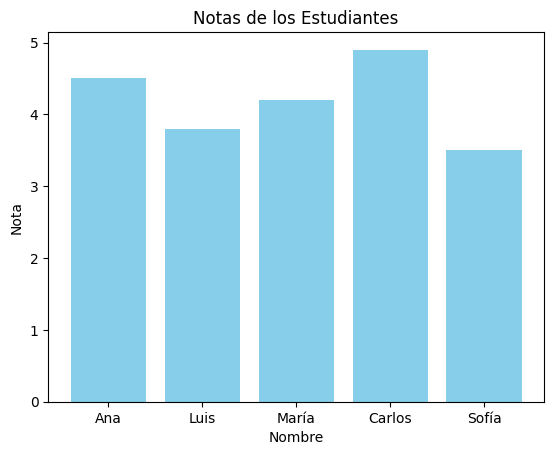

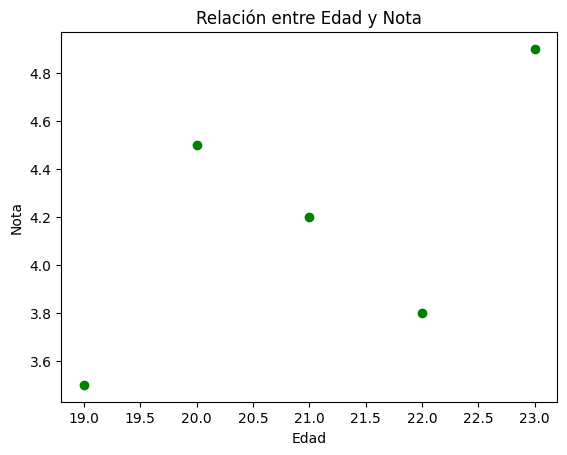


9️⃣ Promedio de notas por género:
 Género
F    4.066667
M    4.350000
Name: Nota, dtype: float64

🔟 Rango: 1.4000000000000004
Varianza: 0.30700000000000016
Desviación estándar: 0.5540758070878029


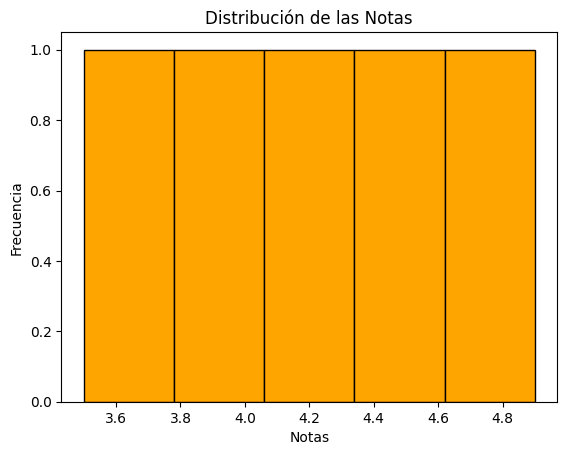

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 4. Crear DataFrame
df = pd.DataFrame({
    'Nombre': ['Ana', 'Luis', 'María', 'Carlos', 'Sofía'],
    'Edad': [20, 22, 21, 23, 19],
    'Nota': [4.5, 3.8, 4.2, 4.9, 3.5]
})

print("4️⃣ DataFrame:\n", df)

# 5. Estadísticas descriptivas
print("\n5️⃣ Estadísticas de las notas:")
print("Media:", df['Nota'].mean())
print("Mínima:", df['Nota'].min())
print("Máxima:", df['Nota'].max())
print("Desviación estándar:", df['Nota'].std())

# 6. Filtrar estudiantes con nota >= 4.0
mayores_4 = df[df['Nota'] >= 4.0]
print("\n6️⃣ Estudiantes con nota >= 4.0:\n", mayores_4)

# 7. Gráfico de barras de notas
plt.figure()
plt.bar(df['Nombre'], df['Nota'], color='skyblue')
plt.title("Notas de los Estudiantes")
plt.xlabel("Nombre")
plt.ylabel("Nota")
plt.show()

# 8. Gráfico de dispersión Edad vs Nota
plt.figure()
plt.scatter(df['Edad'], df['Nota'], color='green')
plt.title("Relación entre Edad y Nota")
plt.xlabel("Edad")
plt.ylabel("Nota")
plt.show()

# 9. Agregar columna Género y calcular promedio por género
df['Género'] = ['F', 'M', 'F', 'M', 'F']
promedio_genero = df.groupby('Género')['Nota'].mean()
print("\n9️⃣ Promedio de notas por género:\n", promedio_genero)

# 10. Rango, varianza y desviación estándar con histograma
rango = df['Nota'].max() - df['Nota'].min()
varianza = df['Nota'].var()
desviacion = df['Nota'].std()
print("\n🔟 Rango:", rango)
print("Varianza:", varianza)
print("Desviación estándar:", desviacion)

plt.figure()
plt.hist(df['Nota'], bins=5, color='orange', edgecolor='black')
plt.title("Distribución de las Notas")
plt.xlabel("Notas")
plt.ylabel("Frecuencia")
plt.show()

Add `%load_ext cudf.pandas` before importing pandas to speed up operations using GPU

In [ ]:
import math
import numpy as np

# ==============================================
# 📘 Estadística Inferencial - Ejemplo práctico
# ==============================================

# Datos muestrales (tiempo promedio en minutos)
datos = np.array([
    14, 16, 15, 18, 17, 14, 13, 16, 15, 17,
        18, 19, 14, 15, 16, 20, 17, 14, 15, 16,
            17, 18, 15, 16, 14, 13, 17, 18, 16, 15
            ])

            # Hipótesis:
            # H0: μ = 15
            # H1: μ ≠ 15
            mu0 = 15
            alpha = 0.05

            # ==============================================
            # 📊 Estadísticas descriptivas
            # ==============================================
            n = len(datos)
            media = np.mean(datos)
            desv = np.std(datos, ddof=1)  # desviación muestral
            sem = desv / math.sqrt(n)     # error estándar de la media

            print("📊 Estadísticas descriptivas:")
            print(f"Tamaño de muestra: {n}")
            print(f"Media muestral: {media:.2f}")
            print(f"Desviación estándar: {desv:.2f}")
            print(f"Error estándar: {sem:.4f}")

            # ==============================================
            # 🧮 Cálculo de la prueba t (manual)
            # ==============================================
            t_stat = (media - mu0) / sem

            # Valor crítico t (aproximado con función inversa normal estándar)
            # Como online-python no tiene scipy, usamos un valor t aproximado para 95% (gl ≈ 30)
            t_critico = 2.045

            print("\n🧮 Resultados de la prueba t:")
            print(f"t calculado = {t_stat:.4f}")
            print(f"t crítico (95%) = ±{t_critico}")

            if abs(t_stat) > t_critico:
                print(f"\n✅ Como |t| > {t_critico}, rechazamos H₀: la media poblacional probablemente no es 15.")
                else:
                    print(f"\n❌ Como |t| ≤ {t_critico}, no rechazamos H₀: no hay evidencia suficiente para decir que la media difiere de 15.")

                    # ==============================================
                    # 📦 Intervalo de confianza al 95%
                    # ==============================================
                    lim_inf = media - t_critico * sem
                    lim_sup = media + t_critico * sem

                    print(f"\n📦 Intervalo de confianza al 95%: ({lim_inf:.2f}, {lim_sup:.2f})")

                    # ==============================================
                    # 🧠 Conclusión final
                    # ==============================================
                    print("\n🧠 Interpretación final:")
                    print(f"La media muestral es {media:.2f} minutos.")
                    print("El intervalo de confianza muestra el rango probable de la media poblacional.")
                    print("Si el valor hipotético (15) cae dentro del intervalo, no hay evidencia fuerte para rechazar H₀.")
